-------------**PROSPECT THEORY (BEKLENTİ TEORİSİ)**----------

Aşağıda prospect teori ile ilgili kodlar bulunmaktadır. Kod 1 ile kod 2 arasındaki farklar:

iki kod arasındaki farkları açıklayalım:

KOD 1:

Amacı: Bir portföyün zaman içindeki performansını Beklenti Teorisi kullanarak simüle etmek ve bu performansı görselleştirmek.
Özellikleri:
Rastgele getiriler üretir (np.random.uniform).
Portföy değerini gün bazında simüle eder (simulate_portfolio fonksiyonu).
Sonuçları bir grafikte gösterir (matplotlib.pyplot).
Daha fazla parametre ve hesaplama içerir (strateji sayısı, senaryo sayısı, gün sayısı gibi).
Daha karmaşık ve gerçekçi bir simülasyon sunar.

KOD 2:

Amacı: Beklenti Teorisini kullanarak farklı stratejilerin beklenti faydalarını hesaplamak ve en iyi stratejiyi seçmek.
Özellikleri:
Sabit getiri değerleri kullanır (returns listesi).
Portföy simülasyonu yapmaz.
Sadece beklenti faydalarını hesaplar ve en iyi stratejiyi belirler.
Daha basit ve daha az parametre içerir.
Temel Beklenti Teorisi hesaplamalarına odaklanır.

Özetle:

İlk kod, Beklenti Teorisi'ni kullanarak bir portföyün zaman içindeki performansını daha gerçekçi bir şekilde simüle eder ve sonuçları görselleştirir. İkinci kod ise sadece Beklenti Teorisi'nin temel hesaplamalarını yaparak en iyi stratejiyi belirlemeye odaklanır. İki kodun amacı ve kapsamı farklıdır.



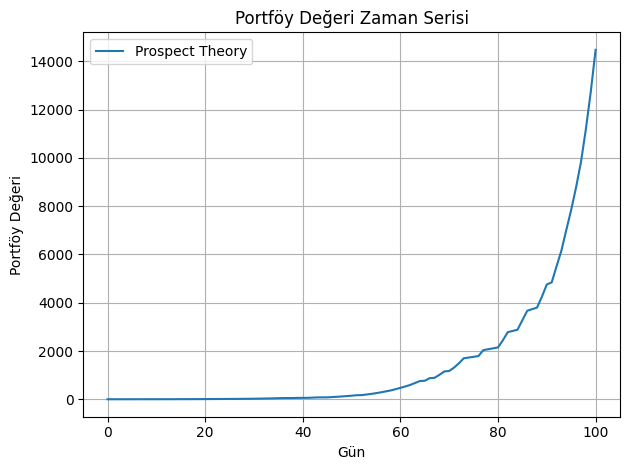

In [6]:
"""
KOD 1:
Kodun Amacı:

Bu kod, Beklenti Teorisi (Prospect Theory) kullanarak bir portföyün zaman içindeki
performansını simüle eder. Beklenti Teorisi, insanların
risk altında nasıl kararlar verdiğini anlatan bir davranışsal ekonomi modelidir.
"""

import numpy as np
import matplotlib.pyplot as plt

#np.random.seed(42)


# Prospect Theory
# Parametreler
n_strategies = 5  # Değerlendirilen strateji sayısı
n_scenarios = 3  # Olası ekonomik senaryo sayısı
scenario_probs = [0.4, 0.35, 0.25]  # Her senaryonun gerçekleşme olasılığı
n_days = 100  # Portföy performansının simüle edileceği gün sayısı

# Simüle edilmiş getiriler: [strateji][senaryo]
# Bu satır, her strateji için her senaryo altında, -0.05 ( %5 kayıp) ile 0.15
# (%15 kazanç) arasında düzgün bir dağılım kullanarak rastgele getiriler oluşturur.
returns = np.random.uniform(-0.05, 0.15, size=(n_strategies, n_scenarios))


# value(x): Beklenti Teorisindeki değer fonksiyonunu temsil eder. Bir kazanç veya kaybın (x) öznel değerini hesaplar.
# weight(p): Beklenti Teorisindeki olasılık ağırlıklandırma fonksiyonunu temsil eder. Bir olasılığa (p) verilen öznel ağırlığı hesaplar.
def value(x, alpha=0.88, lambd=2.25):
    return x**alpha if x >= 0 else -lambd * ((-x)**alpha)

def weight(p, gamma=0.61):
    return (p**gamma) / ((p**gamma + (1 - p)**gamma)**(1 / gamma))

# Beklenti Faydalarını Hesapla:Bu döngü, her strateji için beklenti faydasını hesaplar.
prospect_utilities = []
for i in range(n_strategies):
    v = [value(r) for r in returns[i]]  # Her senaryo için getirilerin değerlerini hesapla
    w = [weight(p) for p in scenario_probs]  # Her senaryo için olasılık ağırlıklarını hesapla
    PT = sum(w_j * v_j for w_j, v_j in zip(w, v))  # Ağırlıklı değerleri topla (Beklenti Faydası)
    prospect_utilities.append(PT)  # Beklenti Faydasını listeye ekle

#En İyi Stratejiyi Seç:
# Bu satır, en yüksek beklenti faydasına sahip stratejinin indeksini (chosen_prospect) bulur.
# np.argmax, bir dizideki maksimum elemanın indeksini döndürür.
chosen_prospect = np.argmax(prospect_utilities)


# Seçilen stratejilere göre günlük getiriler üret (her gün senaryo seç ve stratejiye göre getiri al)
"""
simulate_portfolio(strategy_idx): Belirli bir strateji (strategy_idx) için portföyün günlük değerini n_days boyunca simüle eder.
scenario_probs'a göre rastgele bir senaryo seçer ve seçilen strateji için karşılık gelen getiriyi kullanarak günlük portföy değerini hesaplar.
portfolio_prospect: Seçilen Beklenti Teorisi stratejisi kullanılarak simüle edilen portföy değerlerini depolar."""
def simulate_portfolio(strategy_idx):
    values = [1.0]  # Başlangıç portföy değeri 1.0 olarak ayarlanır
    for _ in range(n_days):
        scenario = np.random.choice(n_scenarios, p=scenario_probs)  # Rastgele bir senaryo seç
        daily_return = returns[strategy_idx][scenario]  # Seçilen senaryo ve stratejiye göre getiriyi al
        values.append(values[-1] * (1 + daily_return))  # Günlük portföy değerini hesapla
    return values


# Portföy simüle et: # Seçilen strateji ile portföyü simüle et

portfolio_prospect = simulate_portfolio(chosen_prospect)


# Görselleştir
# Bu bölüm, seçilen Beklenti Teorisi stratejisi için portföy değerinin zaman içindeki değişimini gösteren bir grafik oluşturur.
# Başlık, eksen etiketleri, açıklama, ızgara çizgileri ekler ve grafiği görüntüler.
plt.plot(portfolio_prospect, label="Prospect Theory")  # Portföy değerlerini çiz
plt.title("Portföy Değeri Zaman Serisi")  # Grafiğe başlık ekle
plt.xlabel("Gün")  # X eksenine etiket ekle
plt.ylabel("Portföy Değeri")  # Y eksenine etiket ekle
plt.legend()  # Açıklama ekle
plt.grid(True)  # Izgara çizgileri ekle
plt.tight_layout()  # Grafiği düzgün bir şekilde yerleştir
plt.show()  # Grafiği göster

Bu kodda strateji seçimi yapılıyor mu

Evet, kodda strateji seçimi yapılıyor. İşte kodun ilgili bölümü:

    prospect_utilities = []
    for i in range(n_strategies):
        v = [value(r) for r in returns[i]]
        w = [weight(p) for p in scenario_probs]
        PT = sum(w_j * v_j for w_j, v_j in zip(w, v))
        prospect_utilities.append(PT)
    chosen_prospect = np.argmax(prospect_utilities)

Açıklama:

prospect_utilities: Bu liste, her stratejinin hesaplanan beklenti faydasını saklamak için kullanılır.

Döngü (for i in range(n_strategies)): Bu döngü, tanımlanan her strateji için beklenti faydasını hesaplar.

chosen_prospect = np.argmax(prospect_utilities): Bu satır, en yüksek beklenti faydasına sahip stratejinin indeksini chosen_prospect değişkenine atar. np.argmax fonksiyonu, bir dizideki (bu durumda prospect_utilities listesi) maksimum değere sahip elemanın indeksini döndürür.

Sonuç:

chosen_prospect değişkeni, en yüksek beklenti faydasına sahip stratejinin indeksini tutar. Bu indeks daha sonra portföy simülasyonunda (simulate_portfolio fonksiyonu) kullanılır. Yani, kod en iyi stratejiyi seçer ve bu stratejiye göre portföyün performansını simüle eder.

Özetle:

kod, Beklenti Teorisi'ni kullanarak stratejilerin beklenti faydalarını hesaplar, en yüksek beklenti faydasına sahip stratejiyi seçer ve bu stratejiye göre portföy performansını simüle eder ve görselleştirir. Dolayısıyla, kodda strateji seçimi yapılmaktadır.

In [3]:
# KOD 2:
# Prospect Theory

import numpy as np

def value(x, alpha=0.88, lambd=2.25):
    return x**alpha if x >= 0 else -lambd * ((-x)**alpha)

def weight(p, gamma=0.61):
    return (p**gamma) / ((p**gamma + (1 - p)**gamma)**(1 / gamma))

# Assume you have 3 strategies for now, please replace with your actual number of strategies.
n_strategies = 3
# Define returns and scenario_probs with sample data
# Replace with your actual data
returns = [[10, 20, 30], [15, 25, 35], [12, 22, 32]]
scenario_probs = [0.2, 0.5, 0.3]

prospect_utilities = []
for i in range(n_strategies):
    v = [value(r) for r in returns[i]]
    w = [weight(p) for p in scenario_probs]
    PT = sum(w_j * v_j for w_j, v_j in zip(w, v))
    prospect_utilities.append(PT)
chosen_prospect = np.argmax(prospect_utilities)

# Print the results
print("Prospect Utilities:", prospect_utilities)
print("Chosen Prospect (index):", chosen_prospect)

Prospect Utilities: [14.200819114266508, 17.24570357507354, 15.429946927923332]
Chosen Prospect (index): 1


**KODUN AÇIKLAMASI:**

Kodun Amacı:

Bu kod, Beklenti Teorisi (Prospect Theory) adı verilen bir karar verme modelini uyguluyor. Beklenti Teorisi, insanların riskli durumlarda nasıl kararlar aldığını açıklamaya çalışan bir teoridir. Teoriye göre, insanlar kazançlar ve kayıplar konusunda farklı davranışlar sergilerler ve olasılıkları değerlendirirken objektif olmaktan ziyade öznel yargılara dayanırlar.

Değer Fonksiyonu (value):

    def value(x, alpha=0.88, lambd=2.25):
          return x**alpha if x >= 0 else -lambd * ((-x)**alpha)

Bu fonksiyon, Beklenti Teorisindeki değer fonksiyonunu temsil eder. Bir sonucun (kazanç veya kayıp) değerini hesaplar. x, sonucun değerini temsil eder. alpha ve lambda, fonksiyonun şeklini kontrol eden parametrelerdir.

Ağırlık Fonksiyonu (weight):

    def weight(p, gamma=0.61):
          return (p**gamma) / ((p**gamma + (1 - p)**gamma)**(1 / gamma))

Bu fonksiyon, Beklenti Teorisindeki ağırlık fonksiyonunu temsil eder. Bir olayın olasılığının, karar verme sürecinde nasıl algılandığını hesaplar. p, olayın olasılığını temsil eder. gamma, fonksiyonun şeklini kontrol eden bir parametredir.

Stratejilerin, Getirilerin ve Olasılıkların Tanımlanması:

    n_strategies = 3
      returns = [[10, 20, 30], [15, 25, 35], [12, 22, 32]]
      scenario_probs = [0.2, 0.5, 0.3]

Bu satırlar, stratejilerin sayısını (n_strategies), her strateji için olası getirileri (returns) ve her senaryonun olasılığını (scenario_probs) tanımlar.

Beklenti Faydalarının Hesaplanması:

    prospect_utilities = []
      for i in range(n_strategies):
          v = [value(r) for r in returns[i]]
          w = [weight(p) for p in scenario_probs]
          PT = sum(w_j * v_j for w_j, v_j in zip(w, v))
          prospect_utilities.append(PT)


Bu döngü, her strateji için beklenti faydasını hesaplar.

v: Her senaryo için getirilerin değer fonksiyonu kullanılarak hesaplanan değerlerini içerir.
w: Her senaryonun olasılığının ağırlık fonksiyonu kullanılarak hesaplanan değerlerini içerir.
PT: Beklenti faydası, ağırlıklandırılmış değerlerin toplamı olarak hesaplanır.

En İyi Stratejinin Seçilmesi:

    chosen_prospect = np.argmax(prospect_utilities)

Bu satır, en yüksek beklenti faydasına sahip stratejinin indeksini (chosen_prospect) bulur.

Sonuçların Yazdırılması:

    print("Prospect Utilities:", prospect_utilities)
    print("Chosen Prospect (index):", chosen_prospect)

Bu satırlar, hesaplanan beklenti faydalarını ve seçilen stratejinin indeksini ekrana yazdırır.

Özetle:

Bu kod, Beklenti Teorisini kullanarak farklı stratejilerin beklenti faydalarını hesaplar ve en yüksek beklenti faydasına sahip stratejiyi seçer. Bu sayede, riskli durumlarda karar verme süreçlerini modellemek ve analiz etmek mümkün olur.


